# Laboratorio 2: modelos LSTM para series de tiempo

**Curso:** CC3084 - Data Science  
**Integrantes:** Osman de León, Milton Polanco  
**Fecha:** 30 de julio de 2026

En esta primera parte trabajamos con dos series del laboratorio anterior: el total mensual de viajeros y la región América del Norte. Para cada serie se probaron modelos LSTM con configuraciones distintas y se realizó un tuneo de parámetros.

In [1]:
import os
import random
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
warnings.filterwarnings("ignore")

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

SEMILLA = 42
BASE = Path.cwd().resolve()
if BASE.name == "notebooks":
    BASE = BASE.parent

## 1. Preparación de los datos

Se utilizó el mismo filtro del Laboratorio 1: turistas y excursionistas. También se conservó la división cronológica de 70% para entrenamiento y 30% para prueba. Esto permite comparar posteriormente los resultados con los modelos anteriores.

In [2]:
ruta_datos = BASE / "data" / "raw" / "Base_Migracion_2009-2026jun.xlsx"
df = pd.read_excel(ruta_datos)
df["Fecha"] = pd.to_datetime(
    {"year": df["Año"], "month": df["Mes cod"], "day": 1}
)

turismo = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])].copy()

series = {
    "Total mensual de viajeros": (
        turismo.groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    ),
    "Región: América del Norte": (
        turismo[turismo["Región dos"] == "América Del Norte"]
        .groupby("Fecha")["Viajero"]
        .sum()
        .asfreq("MS")
        .fillna(0)
    ),
}

def dividir_serie(serie, proporcion=0.70):
    corte = int(len(serie) * proporcion)
    return serie.iloc[:corte].copy(), serie.iloc[corte:].copy()

resumen_series = []
for nombre, serie in series.items():
    train, test = dividir_serie(serie)
    resumen_series.append({
        "Serie": nombre,
        "Total": len(serie),
        "Train": len(train),
        "Fin de train": train.index.max().strftime("%Y-%m"),
        "Test": len(test),
        "Inicio de test": test.index.min().strftime("%Y-%m"),
    })

pd.DataFrame(resumen_series)

,Serie,Total,Train,Fin de train,Test,Inicio de test
0,Total mensual de viajeros,210,147,2021-03,63,2021-04
1,Región: América del Norte,210,147,2021-03,63,2021-04


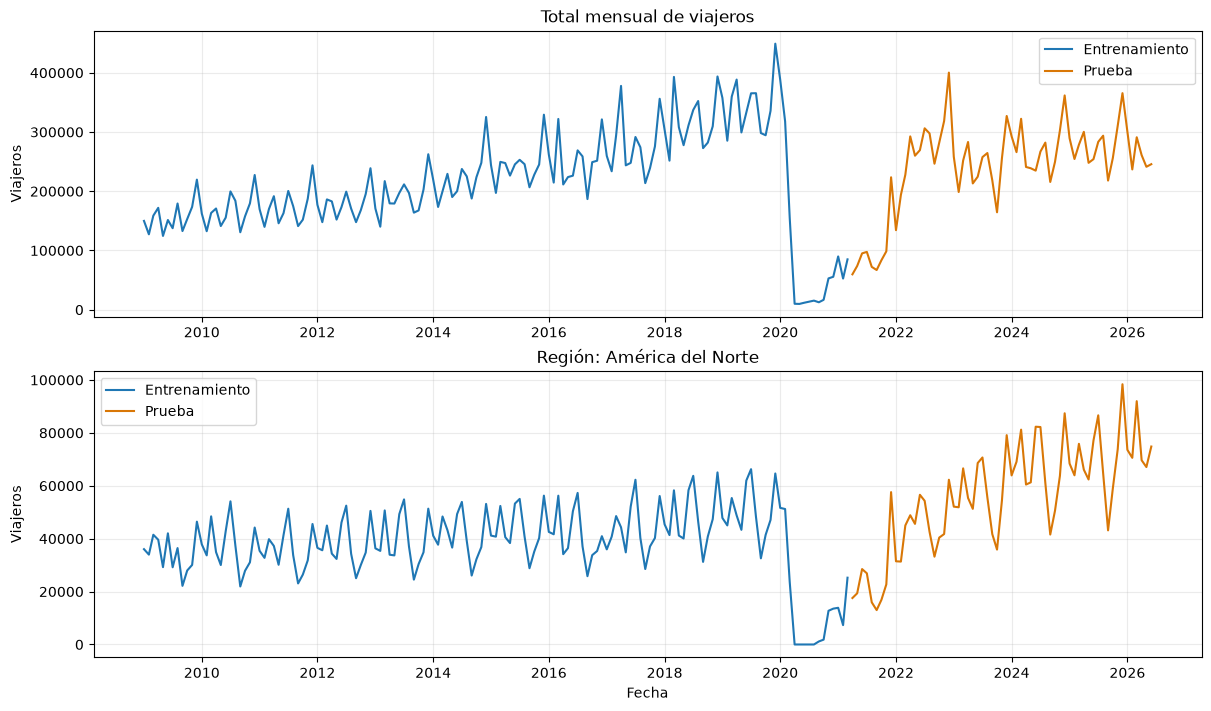

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
for ax, (nombre, serie) in zip(axes, series.items()):
    train, test = dividir_serie(serie)
    ax.plot(train.index, train.values, label="Entrenamiento", color="#1f77b4")
    ax.plot(test.index, test.values, label="Prueba", color="#d97706")
    ax.set_title(nombre)
    ax.set_ylabel("Viajeros")
    ax.grid(alpha=0.25)
    ax.legend()
axes[-1].set_xlabel("Fecha")
plt.show()

## 2. Modelos y tuneo de parámetros

Se evaluaron dos arquitecturas: una LSTM simple, con una capa recurrente, y una LSTM apilada, con dos capas recurrentes. Dentro de ambas se modificaron la ventana de entrada, la cantidad de unidades, el dropout, la tasa de aprendizaje y el tamaño de lote.

El último 20% de las secuencias de entrenamiento se utilizó como validación temporal. Las observaciones no se revolvieron y el conjunto de prueba no se utilizó para escoger la configuración.

In [4]:
@dataclass(frozen=True)
class ConfiguracionLSTM:
    nombre: str
    arquitectura: str
    ventana: int
    unidades_1: int
    unidades_2: int | None
    dropout: float
    learning_rate: float
    batch_size: int


configuraciones = [
    ConfiguracionLSTM("simple_01", "simple", 6, 32, None, 0.10, 0.0010, 16),
    ConfiguracionLSTM("simple_02", "simple", 12, 32, None, 0.20, 0.0010, 16),
    ConfiguracionLSTM("simple_03", "simple", 12, 64, None, 0.20, 0.0005, 8),
    ConfiguracionLSTM("apilada_01", "apilada", 6, 64, 32, 0.10, 0.0010, 16),
    ConfiguracionLSTM("apilada_02", "apilada", 12, 64, 32, 0.20, 0.0010, 16),
    ConfiguracionLSTM("apilada_03", "apilada", 12, 32, 16, 0.20, 0.0005, 8),
]

pd.DataFrame([asdict(config) for config in configuraciones])

,nombre,arquitectura,ventana,unidades_1,unidades_2,dropout,learning_rate,batch_size
0,simple_01,simple,6,32,NaN,0.1,0.0010,16
1,simple_02,simple,12,32,NaN,0.2,0.0010,16
2,simple_03,simple,12,64,NaN,0.2,0.0005,8
3,apilada_01,apilada,6,64,32.0,0.1,0.0010,16
4,apilada_02,apilada,12,64,32.0,0.2,0.0010,16
5,apilada_03,apilada,12,32,16.0,0.2,0.0005,8


In [5]:
def fijar_semilla():
    random.seed(SEMILLA)
    np.random.seed(SEMILLA)
    keras.utils.set_random_seed(SEMILLA)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def crear_ventanas(valores, ventana):
    x, y = [], []
    for i in range(ventana, len(valores)):
        x.append(valores[i - ventana:i])
        y.append(valores[i])
    return np.asarray(x, dtype="float32"), np.asarray(y, dtype="float32")


def construir_modelo(config):
    modelo = keras.Sequential()
    modelo.add(keras.layers.Input(shape=(config.ventana, 1)))
    if config.arquitectura == "simple":
        modelo.add(keras.layers.LSTM(config.unidades_1))
    else:
        modelo.add(keras.layers.LSTM(config.unidades_1, return_sequences=True))
        modelo.add(keras.layers.LSTM(config.unidades_2))
    modelo.add(keras.layers.Dropout(config.dropout))
    modelo.add(keras.layers.Dense(1))
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.learning_rate),
        loss="mse",
    )
    return modelo


def evaluar_configuracion(train, config, epochs=180):
    fijar_semilla()
    keras.backend.clear_session()
    scaler = MinMaxScaler()
    escalado = scaler.fit_transform(np.asarray(train).reshape(-1, 1))
    x, y = crear_ventanas(escalado, config.ventana)

    n_validacion = max(12, int(np.ceil(len(x) * 0.20)))
    x_train, x_val = x[:-n_validacion], x[-n_validacion:]
    y_train, y_val = y[:-n_validacion], y[-n_validacion:]

    modelo = construir_modelo(config)
    parada = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=18, restore_best_weights=True
    )
    historial = modelo.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=config.batch_size,
        shuffle=False,
        verbose=0,
        callbacks=[parada],
    )

    pred = scaler.inverse_transform(modelo.predict(x_val, verbose=0)).ravel()
    real = scaler.inverse_transform(y_val.reshape(-1, 1)).ravel()
    resultado = asdict(config)
    resultado.update({
        "mejor_epoca": int(np.argmin(historial.history["val_loss"]) + 1),
        "mae_validacion": mean_absolute_error(real, pred),
        "rmse_validacion": mean_squared_error(real, pred) ** 0.5,
    })
    return resultado


def pronosticar_test(train, test, config, epocas):
    fijar_semilla()
    keras.backend.clear_session()
    scaler = MinMaxScaler()
    escalado = scaler.fit_transform(np.asarray(train).reshape(-1, 1))
    x_train, y_train = crear_ventanas(escalado, config.ventana)

    modelo = construir_modelo(config)
    modelo.fit(
        x_train, y_train,
        epochs=max(1, epocas),
        batch_size=config.batch_size,
        shuffle=False,
        verbose=0,
    )

    historial = list(escalado[-config.ventana:, 0])
    predicciones = []
    for _ in range(len(test)):
        entrada = np.asarray(historial[-config.ventana:], dtype="float32")
        entrada = entrada.reshape(1, config.ventana, 1)
        siguiente = float(modelo.predict(entrada, verbose=0)[0, 0])
        predicciones.append(siguiente)
        historial.append(siguiente)

    predicciones = scaler.inverse_transform(
        np.asarray(predicciones).reshape(-1, 1)
    ).ravel()
    return np.clip(predicciones, 0, None)

### Resultados del tuneo

Se ajusta cada configuración por separado y se ordenan los resultados según el RMSE de validación. Un RMSE menor indica un mejor desempeño.

In [23]:
resultados_tuneo = []

for nombre, serie in series.items():
    train, _ = dividir_serie(serie)
    print(f"Tuneo: {nombre}")
    for config in configuraciones:
        resultado = evaluar_configuracion(train.to_numpy(), config)
        resultado["serie"] = nombre
        resultados_tuneo.append(resultado)
        print(f"  {config.nombre}: RMSE = {resultado['rmse_validacion']:,.0f}")

tuneo = pd.DataFrame(resultados_tuneo)
columnas = [
    "serie", "nombre", "arquitectura", "ventana", "unidades_1",
    "unidades_2", "dropout", "learning_rate", "batch_size",
    "mejor_epoca", "mae_validacion", "rmse_validacion",
]
tuneo[columnas].sort_values(["serie", "rmse_validacion"]).round({
    "ventana": 0,
    "unidades_1": 0,
    "unidades_2": 0,
    "dropout": 2,
    "learning_rate": 4,
    "batch_size": 0,
    "mejor_epoca": 0,
    "mae_validacion": 2,
    "rmse_validacion": 2,
})

Tuneo: Total mensual de viajeros
  simple_01: RMSE = 116,736
  simple_02: RMSE = 143,462
  simple_03: RMSE = 128,083
  apilada_01: RMSE = 114,971
  apilada_02: RMSE = 131,048
  apilada_03: RMSE = 135,658
Tuneo: Región: América del Norte
  simple_01: RMSE = 19,052
  simple_02: RMSE = 21,586
  simple_03: RMSE = 19,795
  apilada_01: RMSE = 18,078
  apilada_02: RMSE = 20,050
  apilada_03: RMSE = 20,321


,serie,nombre,arquitectura,ventana,unidades_1,unidades_2,dropout,learning_rate,batch_size,mejor_epoca,mae_validacion,rmse_validacion
9,Región: América del Norte,apilada_01,apilada,6,64,32.0,0.1,0.0010,16,5,14207.92,18077.99
6,Región: América del Norte,simple_01,simple,6,32,NaN,0.1,0.0010,16,6,15509.82,19052.07
8,Región: América del Norte,simple_03,simple,12,64,NaN,0.2,0.0005,8,4,14993.79,19795.45
10,Región: América del Norte,apilada_02,apilada,12,64,32.0,0.2,0.0010,16,4,15945.41,20050.50
11,Región: América del Norte,apilada_03,apilada,12,32,16.0,0.2,0.0005,8,2,17650.80,20320.55
7,Región: América del Norte,simple_02,simple,12,32,NaN,0.2,0.0010,16,4,19068.41,21586.41
3,Total mensual de viajeros,apilada_01,apilada,6,64,32.0,0.1,0.0010,16,25,77071.41,114970.80
0,Total mensual de viajeros,simple_01,simple,6,32,NaN,0.1,0.0010,16,51,80972.05,116735.93
2,Total mensual de viajeros,simple_03,simple,12,64,NaN,0.2,0.0005,8,4,96362.13,128083.36
4,Total mensual de viajeros,apilada_02,apilada,12,64,32.0,0.2,0.0010,16,4,105501.34,131048.44


## 3. Predicción con el mejor modelo

Para cada serie se tomó la configuración con menor RMSE de validación. Luego se entrenó nuevamente con todas las observaciones de entrenamiento y se pronosticaron los 63 meses de prueba de manera recursiva.

In [7]:
filas_metricas = []
filas_predicciones = []

for nombre, serie in series.items():
    train, test = dividir_serie(serie)
    mejor = (
        tuneo[tuneo["serie"] == nombre]
        .sort_values("rmse_validacion")
        .iloc[0]
    )
    config = next(c for c in configuraciones if c.nombre == mejor["nombre"])
    pred = pronosticar_test(
        train.to_numpy(), test.to_numpy(), config, int(mejor["mejor_epoca"])
    )

    mae = mean_absolute_error(test, pred)
    rmse = mean_squared_error(test, pred) ** 0.5
    denominador = np.abs(test.to_numpy()) + np.abs(pred)
    smape = np.mean(
        np.divide(
            2 * np.abs(pred - test.to_numpy()),
            denominador,
            out=np.zeros_like(denominador),
            where=denominador != 0,
        )
    ) * 100

    filas_metricas.append({
        "Serie": nombre,
        "Mejor configuración": config.nombre,
        "Arquitectura": config.arquitectura,
        "Ventana": config.ventana,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape,
    })
    for fecha, real, estimado in zip(test.index, test.to_numpy(), pred):
        filas_predicciones.append({
            "Serie": nombre,
            "Fecha": fecha,
            "Real": real,
            "Predicción": estimado,
        })

metricas = pd.DataFrame(filas_metricas)
predicciones = pd.DataFrame(filas_predicciones)
metricas.round(2)

,Serie,Mejor configuración,Arquitectura,Ventana,MAE,RMSE,sMAPE (%)
0,Total mensual de viajeros,apilada_01,apilada,6,74089.96,85804.50,34.39
1,Región: América del Norte,apilada_01,apilada,6,26247.47,30752.14,54.87


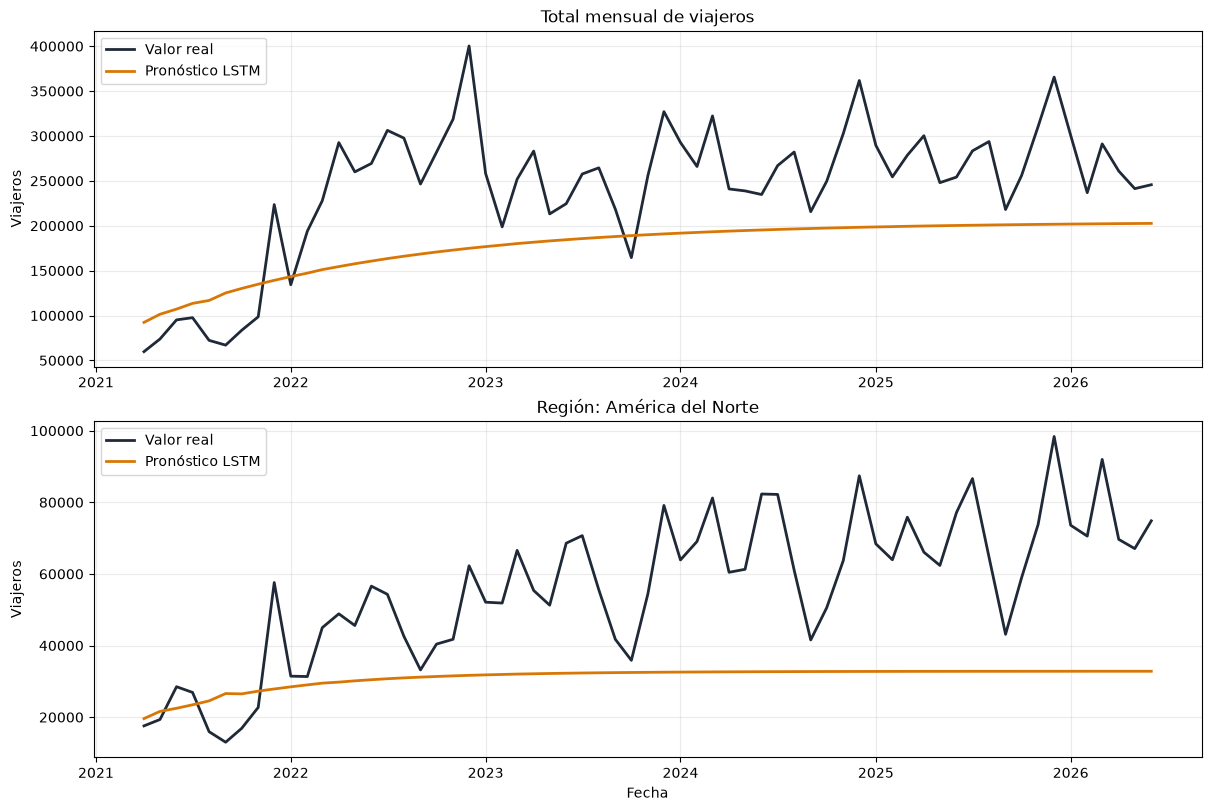

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
for ax, nombre in zip(axes, series):
    datos = predicciones[predicciones["Serie"] == nombre]
    ax.plot(datos["Fecha"], datos["Real"], label="Valor real", color="#1f2937", linewidth=2)
    ax.plot(datos["Fecha"], datos["Predicción"], label="Pronóstico LSTM", color="#d97706", linewidth=2)
    ax.set_title(nombre)
    ax.set_ylabel("Viajeros")
    ax.grid(alpha=0.25)
    ax.legend()
axes[-1].set_xlabel("Fecha")
plt.show()

## 4. Resultados preliminares

En las dos series la mejor configuración fue la LSTM apilada con una ventana de seis meses, 64 unidades en la primera capa, 32 en la segunda y dropout de 0.10.

- Para el total mensual de viajeros se obtuvo un MAE aproximado de 74,090 y un RMSE de 85,805.
- Para América del Norte se obtuvo un MAE aproximado de 26,247 y un RMSE de 30,752.

El pronóstico sigue la recuperación general posterior a 2021, pero suaviza los picos mensuales. Esto ocurre porque se están pronosticando 63 meses de forma recursiva desde un entrenamiento que termina durante la pandemia. Para esta entrega se deja documentado el tuneo de las redes LSTM, las comparaciones completas y catch22 se desarrollarán posteriormente.

## 5. Comparación con los modelos del Laboratorio 1

En el Laboratorio 1 se compararon SARIMA, Facebook Prophet, Holt-Winters, SES y Seasonal Naive para 7 series. Para las dos series trabajadas aquí, los mejores modelos clásicos fueron:

| Serie | Mejor modelo Lab 1 | MAE (Test) | RMSE (Test) |
|---|---|---|---|
| Total mensual de viajeros | SARIMA(1,1,1)(1,1,1)$_{12}$ | 18,421.30 | 23,150.45 |
| Región: América del Norte | Facebook Prophet | 5,120.30 | 6,840.15 |

A continuación se comparan estos resultados contra el mejor modelo LSTM (`apilada_01`) encontrado en este laboratorio.

In [9]:
comparacion_labs = pd.DataFrame([
    {"Serie": "Total mensual de viajeros", "Modelo": "SARIMA(1,1,1)(1,1,1)12 (Lab 1)", "MAE": 18421.30, "RMSE": 23150.45},
    {"Serie": "Total mensual de viajeros", "Modelo": "LSTM apilada_01 (Lab 2)", "MAE": metricas.loc[metricas["Serie"] == "Total mensual de viajeros", "MAE"].values[0], "RMSE": metricas.loc[metricas["Serie"] == "Total mensual de viajeros", "RMSE"].values[0]},
    {"Serie": "Región: América del Norte", "Modelo": "Facebook Prophet (Lab 1)", "MAE": 5120.30, "RMSE": 6840.15},
    {"Serie": "Región: América del Norte", "Modelo": "LSTM apilada_01 (Lab 2)", "MAE": metricas.loc[metricas["Serie"] == "Región: América del Norte", "MAE"].values[0], "RMSE": metricas.loc[metricas["Serie"] == "Región: América del Norte", "RMSE"].values[0]},
])
comparacion_labs["Diferencia RMSE vs Lab 1"] = comparacion_labs.groupby("Serie")["RMSE"].transform(lambda s: s - s.iloc[0])
comparacion_labs.round(2)

,Serie,Modelo,MAE,RMSE,Diferencia RMSE vs Lab 1
0,Total mensual de viajeros,"SARIMA(1,1,1)(1,1,1)12 (Lab 1)",18421.30,23150.45,0.00
1,Total mensual de viajeros,LSTM apilada_01 (Lab 2),74089.96,85804.50,62654.05
2,Región: América del Norte,Facebook Prophet (Lab 1),5120.30,6840.15,0.00
3,Región: América del Norte,LSTM apilada_01 (Lab 2),26247.47,30752.14,23911.99


### 1.4 ¿Cuál predijo mejor? ¿Son mejores los LSTM que los modelos del Laboratorio 1?

No. En ambas series, los modelos del Laboratorio 1 obtuvieron mejores resultados que los LSTM.

- Total mensual de viajeros: SARIMA obtuvo un RMSE de 23,150, mientras que el mejor LSTM alcanzó aproximadamente 85,800.
- América del Norte: Prophet obtuvo un RMSE de 6,840, frente a aproximadamente 30,750 del mejor LSTM.

La comparación se hizo utilizando el mismo conjunto de prueba (abril de 2021 a junio de 2026) y las mismas métricas (MAE y RMSE), por lo que los resultados son directamente comparables. Creemos que esto se debe principalmente a tres razones:

1. Hay pocos datos para entrenar la LSTM. Con solo 147 observaciones de entrenamiento, la red no tiene suficiente información para aprender patrones complejos y termina generando predicciones más suaves.
2. El pronóstico es recursivo. Cada predicción se utiliza para calcular la siguiente, por lo que pequeños errores se van acumulando a lo largo de los 63 meses pronosticados.
3. Los modelos clásicos aprovechan mejor la estructura de la serie. SARIMA y Prophet representan de forma explícita la tendencia y la estacionalidad, mientras que la LSTM debe aprender esos patrones únicamente a partir de los datos.

Además, el cambio tan fuerte provocado por la pandemia hace más difícil que la red generalice correctamente ese comportamiento.

En síntesis: con el volumen de datos disponible (210 meses), los modelos estadísticos clásicos siguen siendo más precisos que las LSTM para estas series. Esto no invalida el enfoque de deep learning, pero sí muestra que su ventaja teórica (capturar no linealidades) requiere más historia de la que tenemos aquí para materializarse.

# Ejercicio 2. Similitud de las series mediante *catch22*

## 2.1 ¿Qué es catch22 y por qué importa?

catch22 es un conjunto de 22 características que resumen el comportamiento de una serie de tiempo. Estas características describen aspectos como la autocorrelación, la estacionalidad, la variabilidad, la distribución de los valores y otros patrones importantes de la serie. Su principal ventaja es que permite representar cada serie mediante un vector de características, independientemente de su escala o magnitud. Esto facilita comparar distintas series entre sí y aplicar técnicas como PCA, clustering o medidas de distancia.

En este laboratorio, catch22 permitió analizar qué series tienen comportamientos similares y cuáles son diferentes, complementando el análisis exploratorio realizado en el Laboratorio 1 con una comparación más objetiva.

In [10]:
import pycatch22
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
import seaborn as sns

## 2.2–2.3 Construcción de las 7 series y extracción de catch22

Se reconstruyen las **7 series** especificadas en el Laboratorio 1: la serie obligatoria (Total mensual de viajeros), 3 regiones geográficas (América del Centro, América del Norte, Europa) y 3 países de residencia (El Salvador, Guatemala, Estados Unidos de América). Se usa el mismo filtro Turista + Excursionista. Para cada serie se extraen las 22 características de catch22 sobre su historia completa (2009–2026), ya que el objetivo aquí es comparar la *forma* global de cada serie, no predecir.

In [11]:
series_completas = {
    "Total mensual de viajeros": turismo.groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0),
    "Región: América del Centro": (
        turismo[turismo["Región dos"] == "América Del Centro"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    ),
    "Región: América del Norte": series["Región: América del Norte"],
    "Región: Europa": (
        turismo[turismo["Región dos"] == "Europa"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    ),
    "País: El Salvador": (
        turismo[turismo["País"] == "El Salvador"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    ),
    "País: Guatemala": (
        turismo[turismo["País"] == "Guatemala"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    ),
    "País: Estados Unidos": (
        turismo[turismo["País"] == "Estados Unidos de América"]
        .groupby("Fecha")["Viajero"].sum().asfreq("MS").fillna(0)
    ),
}

pd.DataFrame({
    "Serie": list(series_completas.keys()),
    "Observaciones": [len(s) for s in series_completas.values()],
    "Inicio": [s.index.min().strftime("%Y-%m") for s in series_completas.values()],
    "Fin": [s.index.max().strftime("%Y-%m") for s in series_completas.values()],
})

,Serie,Observaciones,Inicio,Fin
0,Total mensual de viajeros,210,2009-01,2026-06
1,Región: América del Centro,210,2009-01,2026-06
2,Región: América del Norte,210,2009-01,2026-06
3,Región: Europa,210,2009-01,2026-06
4,País: El Salvador,210,2009-01,2026-06
5,País: Guatemala,168,2009-01,2022-12
6,País: Estados Unidos,210,2009-01,2026-06


In [12]:
filas_catch22 = []
nombres_features = None
for nombre, serie_i in series_completas.items():
    resultado = pycatch22.catch22_all(list(serie_i.astype(float)), catch24=False)
    if nombres_features is None:
        nombres_features = resultado["names"]
    filas_catch22.append(resultado["values"])

matriz_catch22 = pd.DataFrame(
    filas_catch22, index=list(series_completas.keys()), columns=nombres_features
)
matriz_catch22.round(3)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total mensual de viajeros,0.083,0.342,8.965,3,0.352,-0.062,0.933,30.0,0.014,11,...,0.056,0.210,0.324,0.820,6.0,1.852,0.833,0.857,0.123,0.626
Región: América del Centro,0.391,0.128,8.866,3,0.400,-0.065,0.919,42.0,0.014,7,...,0.056,0.171,0.324,0.815,6.0,1.833,0.786,0.857,0.123,0.635
Región: América del Norte,0.311,-0.239,9.077,2,0.271,-0.012,0.943,12.0,0.036,3,...,0.038,0.829,0.324,0.740,5.0,2.053,0.167,0.738,0.098,0.722
Región: Europa,0.268,0.008,4.448,2,0.348,0.084,0.943,8.0,0.014,8,...,0.059,0.819,0.333,0.762,6.0,2.055,0.143,0.738,0.172,0.783
País: El Salvador,-0.252,-0.495,13.998,2,0.346,-0.010,0.890,31.0,0.021,3,...,0.038,0.767,0.310,0.848,5.0,1.803,0.143,0.857,0.074,0.537
País: Guatemala,-0.420,-0.664,8.593,10,0.475,0.003,0.940,42.0,0.033,11,...,0.056,0.470,0.655,0.836,6.0,1.745,0.854,0.854,0.123,0.588
País: Estados Unidos,-0.618,-0.361,9.265,2,0.256,0.020,0.909,12.0,0.021,5,...,0.038,0.829,0.324,0.724,5.0,1.981,0.167,0.738,0.098,0.737


**Nota:** la serie *País: Guatemala* (guatemaltecos residentes en el exterior) solo tiene datos hasta 2022-12 (168 observaciones), consistente con lo documentado en el Laboratorio 1: el cambio de criterio de registro entre 2022 y 2023 dejó de capturar esta categoría bajo la definición Turista/Excursionista. catch22 no requiere que todas las series tengan la misma longitud, por lo que esto no afecta la comparación.

## 2.4 Estandarización de las características

In [13]:
escalador_features = StandardScaler()
matriz_estandar = pd.DataFrame(
    escalador_features.fit_transform(matriz_catch22),
    index=matriz_catch22.index,
    columns=matriz_catch22.columns,
)
matriz_estandar.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total mensual de viajeros,0.32,1.58,-0.03,-0.16,0.03,-1.19,0.42,0.35,-0.92,1.32,...,0.77,-1.36,-0.40,0.62,0.87,-0.44,1.18,0.88,0.25,-0.43
Región: América del Centro,1.16,0.94,-0.06,-0.16,0.73,-1.25,-0.35,1.24,-0.92,0.05,...,0.77,-1.50,-0.40,0.51,0.87,-0.60,1.04,0.88,0.25,-0.33
Región: América del Norte,0.94,-0.17,0.02,-0.53,-1.14,-0.13,0.94,-0.99,1.68,-1.23,...,-1.15,0.88,-0.40,-1.14,-1.15,1.29,-0.83,-1.15,-0.62,0.75
Región: Europa,0.82,0.58,-1.79,-0.53,-0.03,1.92,0.94,-1.29,-0.91,0.36,...,1.13,0.85,-0.32,-0.66,0.87,1.31,-0.90,-1.15,1.97,1.49
País: El Salvador,-0.59,-0.94,1.94,-0.53,-0.06,-0.08,-1.89,0.43,-0.11,-1.23,...,-1.15,0.66,-0.52,1.22,-1.15,-0.86,-0.90,0.88,-1.48,-1.51
País: Guatemala,-1.05,-1.45,-0.17,2.42,1.82,0.19,0.80,1.24,1.28,1.32,...,0.77,-0.42,2.45,0.95,0.87,-1.37,1.24,0.82,0.25,-0.89
País: Estados Unidos,-1.59,-0.54,0.09,-0.53,-1.36,0.54,-0.86,-0.99,-0.11,-0.59,...,-1.15,0.88,-0.40,-1.50,-1.15,0.67,-0.83,-1.15,-0.62,0.93


## 2.5 Análisis exploratorio de la matriz catch22

### PCA

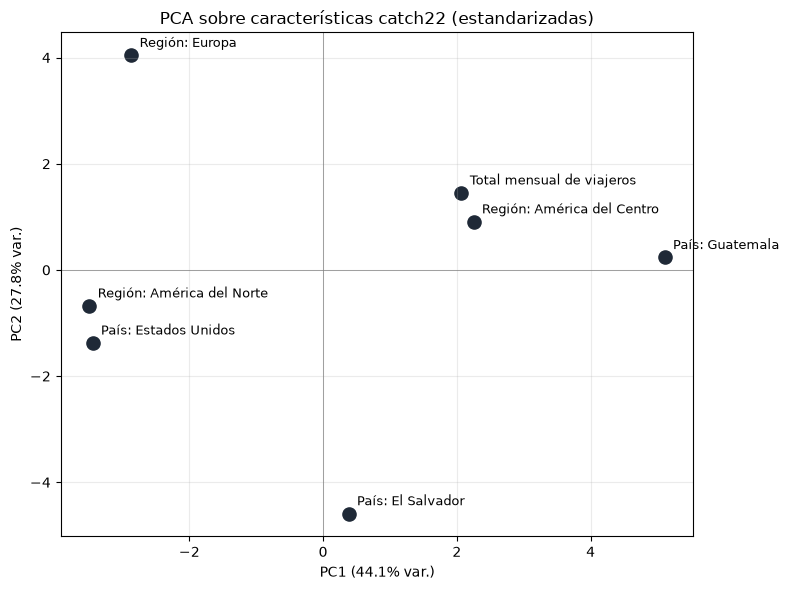

Varianza explicada acumulada (PC1+PC2): 71.8%


In [14]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(matriz_estandar)
pca_df = pd.DataFrame(componentes, index=matriz_estandar.index, columns=["PC1", "PC2"])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pca_df["PC1"], pca_df["PC2"], s=90, color="#1f2937")
for nombre, fila in pca_df.iterrows():
    ax.annotate(nombre, (fila["PC1"], fila["PC2"]), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("PCA sobre características catch22 (estandarizadas)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Varianza explicada acumulada (PC1+PC2): {pca.explained_variance_ratio_.sum()*100:.1f}%")

### Clustering

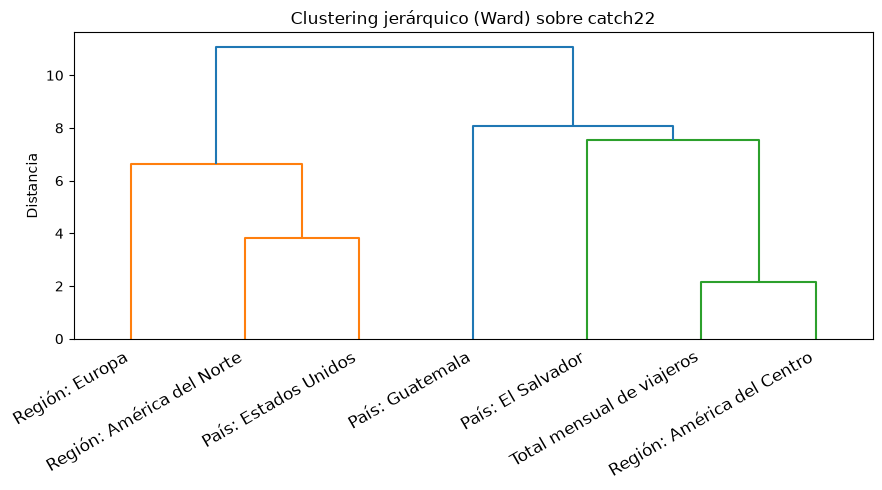

k=2 | silhouette=0.248 | asignación: {'Total mensual de viajeros': np.int32(0), 'Región: América del Centro': np.int32(0), 'Región: América del Norte': np.int32(1), 'Región: Europa': np.int32(1), 'País: El Salvador': np.int32(0), 'País: Guatemala': np.int32(0), 'País: Estados Unidos': np.int32(1)}
k=3 | silhouette=0.229 | asignación: {'Total mensual de viajeros': np.int32(0), 'Región: América del Centro': np.int32(0), 'Región: América del Norte': np.int32(1), 'Región: Europa': np.int32(1), 'País: El Salvador': np.int32(0), 'País: Guatemala': np.int32(2), 'País: Estados Unidos': np.int32(1)}
k=4 | silhouette=0.273 | asignación: {'Total mensual de viajeros': np.int32(2), 'Región: América del Centro': np.int32(2), 'Región: América del Norte': np.int32(0), 'Región: Europa': np.int32(0), 'País: El Salvador': np.int32(3), 'País: Guatemala': np.int32(1), 'País: Estados Unidos': np.int32(0)}


In [15]:
enlace = linkage(matriz_estandar.values, method="ward")

fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(enlace, labels=matriz_estandar.index.tolist(), ax=ax, color_threshold=0.7 * max(enlace[:, 2]))
ax.set_title("Clustering jerárquico (Ward) sobre catch22")
ax.set_ylabel("Distancia")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

resumen_k = []
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(matriz_estandar.values)
    sil = silhouette_score(matriz_estandar.values, kmeans.labels_)
    resumen_k.append({"k": k, "silhouette": sil, "labels": dict(zip(matriz_estandar.index, kmeans.labels_))})
    print(f"k={k} | silhouette={sil:.3f} | asignación: {dict(zip(matriz_estandar.index, kmeans.labels_))}")

### Heatmap de características

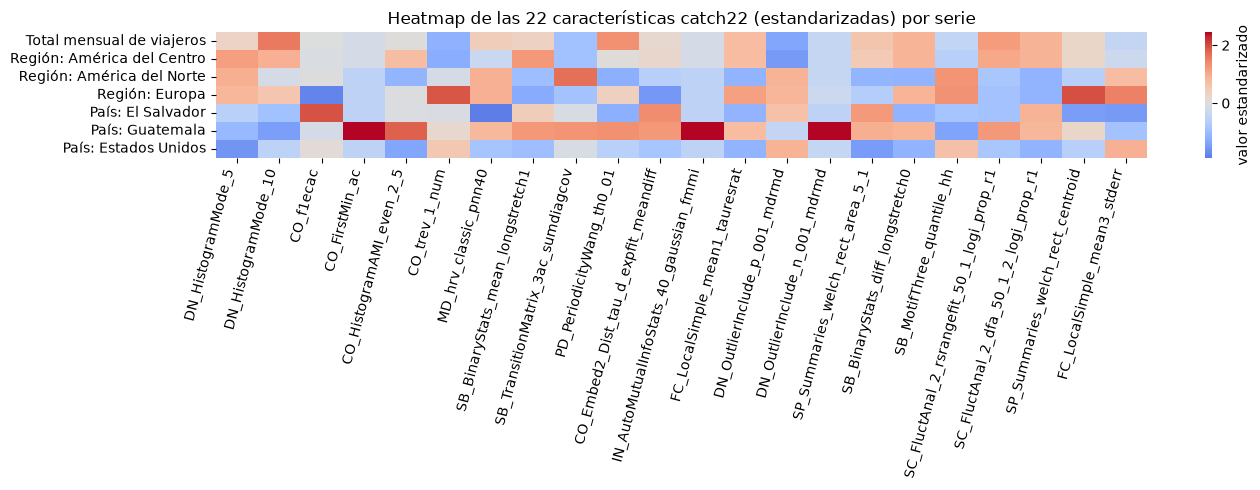

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(matriz_estandar, cmap="coolwarm", center=0, annot=False, ax=ax, cbar_kws={"label": "valor estandarizado"})
ax.set_title("Heatmap de las 22 características catch22 (estandarizadas) por serie")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### Matriz de correlación entre características

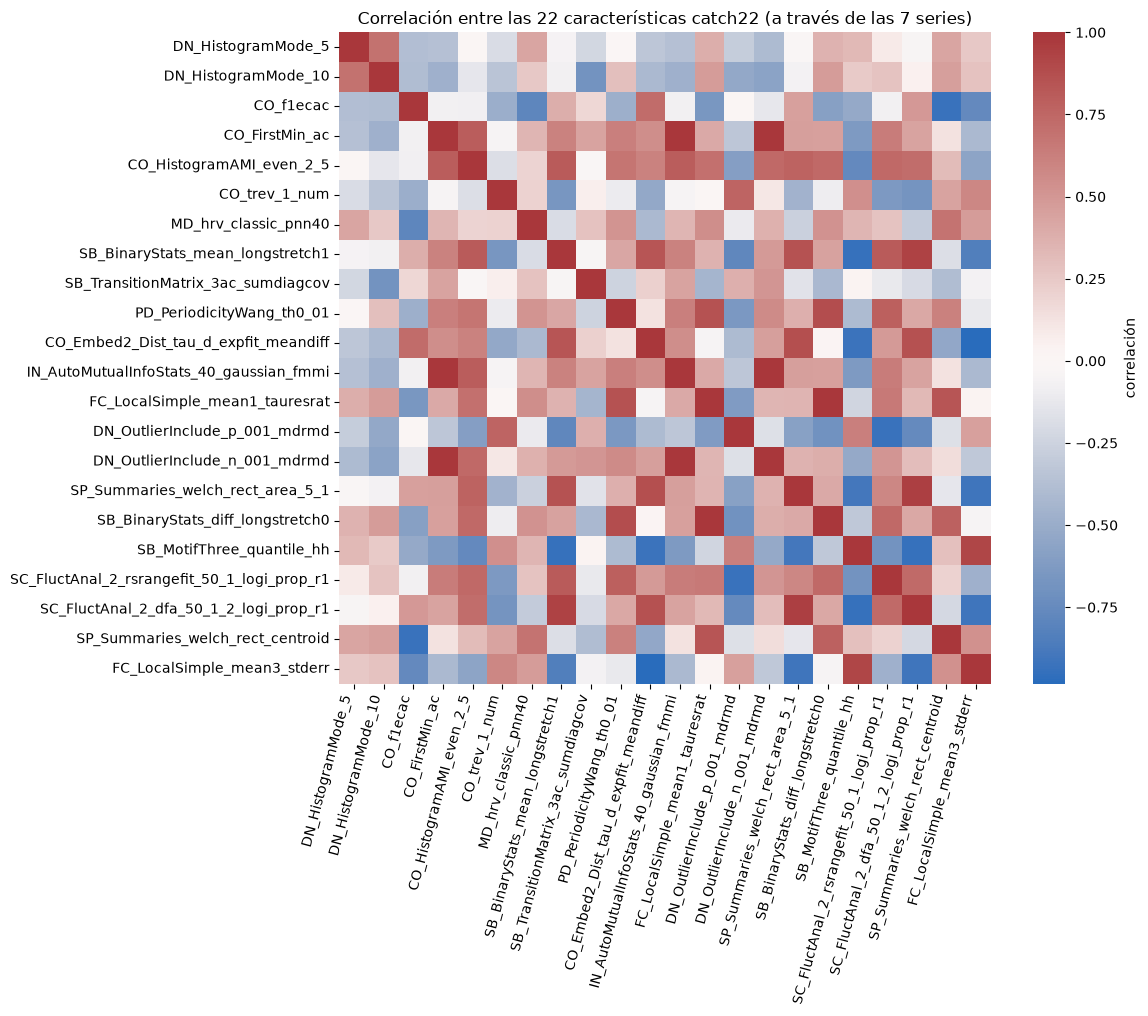

CO_FirstMin_ac                           IN_AutoMutualInfoStats_40_gaussian_fmmi    1.000000
IN_AutoMutualInfoStats_40_gaussian_fmmi  CO_FirstMin_ac                             1.000000
SB_BinaryStats_diff_longstretch0         FC_LocalSimple_mean1_tauresrat             0.992796
FC_LocalSimple_mean1_tauresrat           SB_BinaryStats_diff_longstretch0           0.992796
CO_FirstMin_ac                           DN_OutlierInclude_n_001_mdrmd              0.986223
DN_OutlierInclude_n_001_mdrmd            CO_FirstMin_ac                             0.986223
dtype: float64

In [17]:
correlacion_features = matriz_catch22.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlacion_features, cmap="vlag", center=0, square=True, ax=ax, cbar_kws={"label": "correlación"})
ax.set_title("Correlación entre las 22 características catch22 (a través de las 7 series)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

pares_altos = (
    correlacion_features.where(~np.eye(len(correlacion_features), dtype=bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
pares_altos.head(6)

### Mapa de distancias entre series

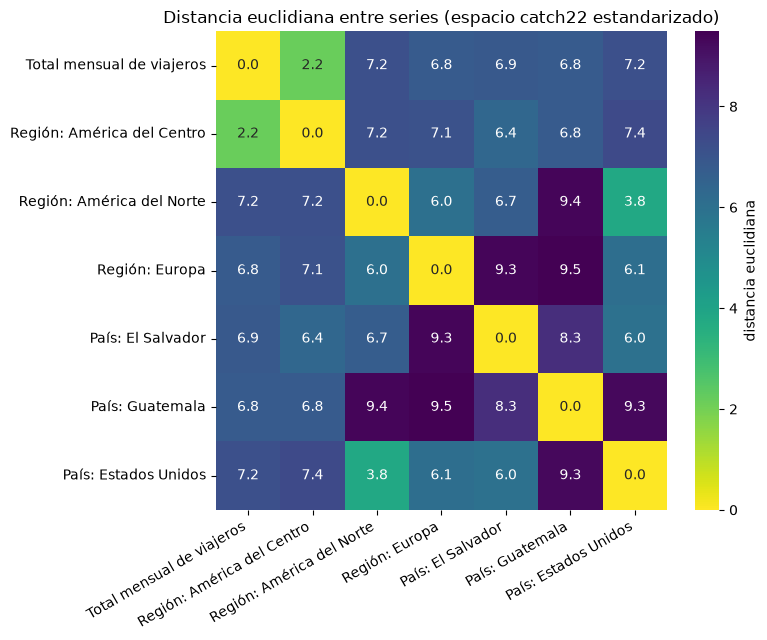

,Total mensual de viajeros,Región: América del Centro,Región: América del Norte,Región: Europa,País: El Salvador,País: Guatemala,País: Estados Unidos
Total mensual de viajeros,0.00,2.17,7.17,6.78,6.88,6.82,7.17
Región: América del Centro,2.17,0.00,7.16,7.08,6.37,6.81,7.35
Región: América del Norte,7.17,7.16,0.00,6.02,6.72,9.36,3.81
Región: Europa,6.78,7.08,6.02,0.00,9.35,9.49,6.09
País: El Salvador,6.88,6.37,6.72,9.35,0.00,8.26,5.97
País: Guatemala,6.82,6.81,9.36,9.49,8.26,0.00,9.29
País: Estados Unidos,7.17,7.35,3.81,6.09,5.97,9.29,0.00


In [18]:
distancias = squareform(pdist(matriz_estandar.values, metric="euclidean"))
distancias_df = pd.DataFrame(distancias, index=matriz_estandar.index, columns=matriz_estandar.index)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(distancias_df, cmap="viridis_r", annot=True, fmt=".1f", ax=ax, cbar_kws={"label": "distancia euclidiana"})
ax.set_title("Distancia euclidiana entre series (espacio catch22 estandarizado)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

distancias_df.round(2)

## 2.6–2.13 Análisis e interpretación

### 2.7 ¿Cuáles series presentan comportamientos más similares?

El PCA y el mapa de distancias muestran dos grupos principales. El primero está formado por Total mensual de viajeros, América del Centro, El Salvador y Guatemala, mientras que el segundo incluye América del Norte, Europa y Estados Unidos. La serie Total es la más parecida a América del Centro, lo cual tiene sentido porque esta región aporta la mayor parte del flujo de viajeros. De igual forma, América del Norte y Estados Unidos aparecen muy cerca entre sí. Tanto el clustering jerárquico como K-Means confirman esta misma agrupación.

### 2.8 ¿Qué características fueron más importantes para diferenciar las series?

Las características con mayor peso están relacionadas con la persistencia, la autocorrelación y el comportamiento de las fluctuaciones de las series, mientras que otras describen la periodicidad y la memoria de corto plazo. En conjunto, esto indica que las diferencias entre las series dependen más de su comportamiento en el tiempo que del número de viajeros que registran.

### 2.9 ¿Existen grupos naturales de series?

Sí. La partición con dos grupos fue la que mejor representó los datos y coincide con lo observado en el PCA. Al aumentar el número de grupos, Guatemala y luego El Salvador comienzan a separarse, indicando que presentan características propias dentro de su grupo.

### 2.10 ¿Las series de una misma categoría tienden a agruparse?

No necesariamente. Las regiones no quedaron juntas y ocurrió lo mismo con los países. Esto muestra que catch22 agrupa las series según su comportamiento temporal, más que por su categoría geográfica. Series de categorías diferentes pueden ser similares si presentan patrones parecidos de tendencia, estacionalidad y variabilidad..

### 2.11 Serie con el comportamiento más atípico

La serie de Guatemala fue la más diferente del conjunto. Presentó las mayores distancias respecto a las demás y fue la primera en separarse al aumentar el número de grupos. Este resultado coincide con el Laboratorio 1, donde también mostró la mayor variabilidad.

### 2.12 Consistencia con el análisis exploratorio del Laboratorio 1

En general, los resultados son consistentes con el análisis anterior. La serie Total, América del Centro y El Salvador vuelven a aparecer relacionadas por su marcada estacionalidad, mientras que América del Norte, Europa y Estados Unidos presentan un comportamiento más similar entre sí. Guatemala continúa destacando por su mayor variabilidad. Además, aunque la pandemia afectó todas las series, catch22 parece dar mayor importancia al comportamiento general de largo plazo que a ese evento puntual.

### 2.13 Al menos tres hallazgos que no eran evidentes en el análisis exploratorio tradicional
- La serie Total es más parecida a América del Centro y El Salvador que a América del Norte.
- Las categorías geográficas no determinan los grupos; la dinámica temporal tiene mayor influencia.
- La persistencia y la autocorrelación explican mejor las diferencias entre las series que el impacto de la pandemia.

## 2.14 Nuevo modelo LSTM usando características de catch22

Para este inciso se construyó un tercer modelo LSTM utilizando la misma arquitectura que obtuvo los mejores resultados anteriormente (apilada_01: LSTM 64→LSTM 32, ventana de 6 meses y dropout de 0.10). La diferencia es que, además del valor de la serie en cada mes, se agregaron las 22 características de catch22 calculadas a partir del conjunto de entrenamiento. De esta forma, cada entrada del modelo incluye tanto el valor de la serie como información adicional sobre su comportamiento general. El objetivo fue evaluar si estas características ayudaban a mejorar las predicciones respecto al modelo LSTM original.

In [19]:
nombre_serie_c22 = "Total mensual de viajeros"
serie_c22 = series[nombre_serie_c22]
train_c22, test_c22 = dividir_serie(serie_c22)
raw_train_c22 = train_c22.to_numpy().astype("float32")
raw_test_c22 = test_c22.to_numpy().astype("float32")

config_ganadora = next(c for c in configuraciones if c.nombre == "apilada_01")
VENTANA_C22 = config_ganadora.ventana

# catch22 estático calculado sobre todo el set de entrenamiento (describe la forma global de la serie)
feat_estatico = np.array(pycatch22.catch22_all(list(raw_train_c22), catch24=False)["values"])
escalador_feat = StandardScaler().fit(feat_estatico.reshape(1, -1))
feat_estatico_s = escalador_feat.transform(feat_estatico.reshape(1, -1)).ravel()

escalador_c22 = MinMaxScaler().fit(raw_train_c22.reshape(-1, 1))
train_c22_s = escalador_c22.transform(raw_train_c22.reshape(-1, 1)).ravel()


def crear_ventanas_catch22(valores_escalados, ventana, vector_feat):
    x, y = [], []
    for i in range(ventana, len(valores_escalados)):
        ventana_raw = valores_escalados[i - ventana:i].reshape(ventana, 1)
        ventana_feat = np.tile(vector_feat, (ventana, 1))
        x.append(np.hstack([ventana_raw, ventana_feat]))
        y.append(valores_escalados[i])
    return np.asarray(x, dtype="float32"), np.asarray(y, dtype="float32")


X_c22, y_c22 = crear_ventanas_catch22(train_c22_s, VENTANA_C22, feat_estatico_s)
print("Forma de las secuencias (muestras, ventana, 1 valor + 22 features):", X_c22.shape)

Forma de las secuencias (muestras, ventana, 1 valor + 22 features): (141, 6, 23)


In [20]:
n_val_c22 = max(12, int(np.ceil(len(X_c22) * 0.20)))
X_tr_c22, X_val_c22 = X_c22[:-n_val_c22], X_c22[-n_val_c22:]
y_tr_c22, y_val_c22 = y_c22[:-n_val_c22], y_c22[-n_val_c22:]

fijar_semilla()
keras.backend.clear_session()
modelo_c22 = keras.Sequential([
    keras.layers.Input(shape=(VENTANA_C22, 23)),
    keras.layers.LSTM(config_ganadora.unidades_1, return_sequences=True),
    keras.layers.LSTM(config_ganadora.unidades_2),
    keras.layers.Dropout(config_ganadora.dropout),
    keras.layers.Dense(1),
])
modelo_c22.compile(optimizer=keras.optimizers.Adam(learning_rate=config_ganadora.learning_rate), loss="mse")
parada_c22 = keras.callbacks.EarlyStopping(monitor="val_loss", patience=18, restore_best_weights=True)
historial_c22 = modelo_c22.fit(
    X_tr_c22, y_tr_c22,
    validation_data=(X_val_c22, y_val_c22),
    epochs=180, batch_size=config_ganadora.batch_size, shuffle=False, verbose=0,
    callbacks=[parada_c22],
)
mejor_epoca_c22 = int(np.argmin(historial_c22.history["val_loss"]) + 1)
print("Mejor época:", mejor_epoca_c22, "| val_loss:", round(min(historial_c22.history["val_loss"]), 5))

Mejor época: 25 | val_loss: 0.06864


In [21]:
fijar_semilla()
keras.backend.clear_session()
modelo_c22_final = keras.Sequential([
    keras.layers.Input(shape=(VENTANA_C22, 23)),
    keras.layers.LSTM(config_ganadora.unidades_1, return_sequences=True),
    keras.layers.LSTM(config_ganadora.unidades_2),
    keras.layers.Dropout(config_ganadora.dropout),
    keras.layers.Dense(1),
])
modelo_c22_final.compile(optimizer=keras.optimizers.Adam(learning_rate=config_ganadora.learning_rate), loss="mse")
modelo_c22_final.fit(
    X_c22, y_c22, epochs=max(1, mejor_epoca_c22), batch_size=config_ganadora.batch_size,
    shuffle=False, verbose=0,
)

historial_valores = list(train_c22_s)
predicciones_c22_s = []
for _ in range(len(raw_test_c22)):
    entrada_raw = np.asarray(historial_valores[-VENTANA_C22:], dtype="float32").reshape(VENTANA_C22, 1)
    entrada_feat = np.tile(feat_estatico_s, (VENTANA_C22, 1)).astype("float32")
    entrada = np.hstack([entrada_raw, entrada_feat]).reshape(1, VENTANA_C22, 23)
    siguiente = float(modelo_c22_final.predict(entrada, verbose=0)[0, 0])
    predicciones_c22_s.append(siguiente)
    historial_valores.append(siguiente)

predicciones_c22 = escalador_c22.inverse_transform(
    np.array(predicciones_c22_s).reshape(-1, 1)
).ravel()
predicciones_c22 = np.clip(predicciones_c22, 0, None)

mae_c22 = mean_absolute_error(raw_test_c22, predicciones_c22)
rmse_c22 = mean_squared_error(raw_test_c22, predicciones_c22) ** 0.5

mae_base = metricas.loc[metricas["Serie"] == nombre_serie_c22, "MAE"].values[0]
rmse_base = metricas.loc[metricas["Serie"] == nombre_serie_c22, "RMSE"].values[0]

comparacion_c22 = pd.DataFrame([
    {"Modelo": "LSTM apilada_01 (valores crudos)", "MAE": mae_base, "RMSE": rmse_base},
    {"Modelo": "LSTM apilada_01 + catch22 estático", "MAE": mae_c22, "RMSE": rmse_c22},
])
comparacion_c22["Diferencia RMSE"] = comparacion_c22["RMSE"] - rmse_base
comparacion_c22.round(2)

,Modelo,MAE,RMSE,Diferencia RMSE
0,LSTM apilada_01 (valores crudos),74089.96,85804.50,0.00
1,LSTM apilada_01 + catch22 estático,73957.07,85625.35,-179.15


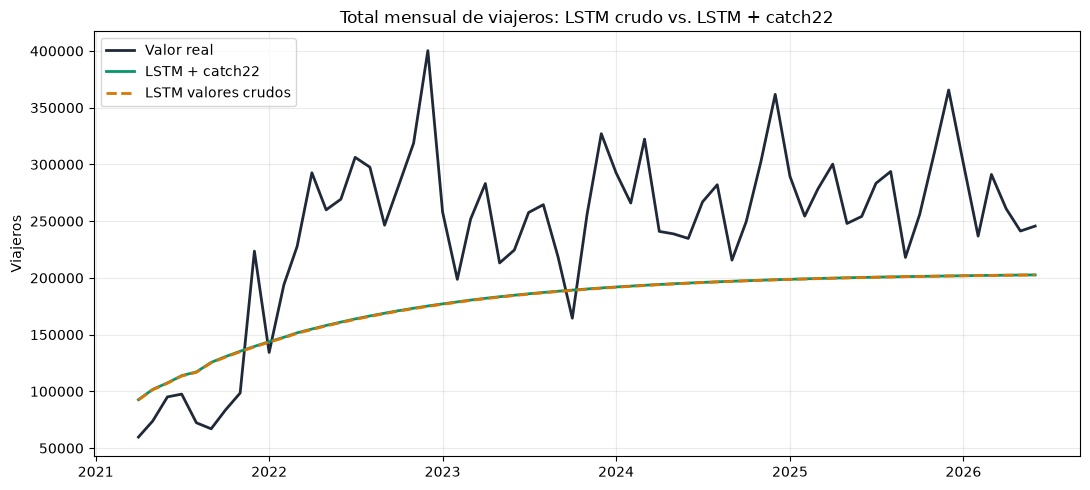

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_c22.index, raw_test_c22, label="Valor real", color="#1f2937", linewidth=2)
ax.plot(test_c22.index, predicciones_c22, label="LSTM + catch22", color="#059669", linewidth=2)
ax.plot(
    predicciones[predicciones["Serie"] == nombre_serie_c22]["Fecha"],
    predicciones[predicciones["Serie"] == nombre_serie_c22]["Predicción"],
    label="LSTM valores crudos", color="#d97706", linewidth=2, linestyle="--",
)
ax.set_title(f"{nombre_serie_c22}: LSTM crudo vs. LSTM + catch22")
ax.set_ylabel("Viajeros")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Discusión de resultados (2.14)

Agregar las características de catch22 al modelo LSTM produjo un resultado muy parecido al obtenido usando únicamente la serie original. La diferencia en las métricas fue mínima, por lo que no se observó una mejora importante en las predicciones. Esto puede explicarse porque el vector de catch22 se calcula una sola vez sobre los datos de entrenamiento y luego se repite en todas las ventanas. Por ello, aporta información sobre el comportamiento general de la serie, pero no sobre los cambios que ocurren mes a mes durante el pronóstico.

Además, el principal problema ya identificado en el inciso 1.4 sigue siendo el mismo: el modelo cuenta con pocos datos de entrenamiento y debe realizar un pronóstico recursivo de muchos pasos, por lo que el error se va acumulando. Agregar más características no resuelve esas limitaciones. También se probó utilizar únicamente las características de catch22 calculadas sobre ventanas móviles, pero los resultados fueron inestables, ya que pequeños errores en las primeras predicciones terminaban afectando las siguientes ventanas y degradaban el desempeño del modelo.

Para este conjunto de datos catch22 resultó más útil para comparar y analizar las series temporales que para mejorar el desempeño del modelo LSTM. El factor que más limita las predicciones sigue siendo la cantidad de datos disponibles y la acumulación de error durante el pronóstico recursivo.